Read about automatic differentation in "Machine Learning Defined" appendix B. You can find that online here
https://jermwatt.github.io/machine_learning_refined/notes/3_First_order_methods/3_5_Automatic.html
To make the module autograd available we use the following commands:

In [11]:
# import statement for autograd wrapped numpy
import autograd.numpy as np   
from autograd import grad  
import matplotlib.pyplot as plt
from MLRPlotting import static_plotter
#import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

Then we can use the following generic code for doing the gradient descent:

In [12]:
# import automatic differentiator to compute gradient module
from autograd import grad 

# gradient descent function - inputs: g (input function), alpha (steplength parameter), max_its (maximum number of iterations), w (initialization)
def gradient_descent(g,alpha,max_its,w):
    # compute gradient module using autograd
    gradient = grad(g)

    # run the gradient descent loop
    weight_history = [w]           # container for weight history
    cost_history = [g(w)]          # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_eval = gradient(w)

        # take gradient descent step
        w = w - alpha*grad_eval
        
        # record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))
    return weight_history,cost_history

We now want to find the minimum of 
$$g(w)=\frac{1}{50}(w^4+w^2+10w)$$ using the above gradient descent. Make three separate runs using a step length of $\alpha$=1,0.1 and 0.01 starting from $w^0=2$ with 1,000 iterations. Plot the resulting cost histories. Which step length works best for this particular function and initial point ?

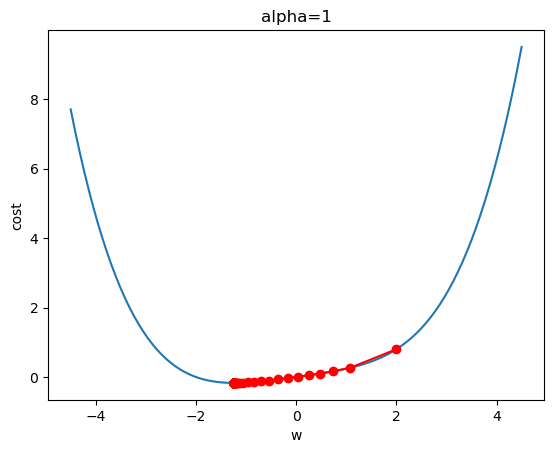

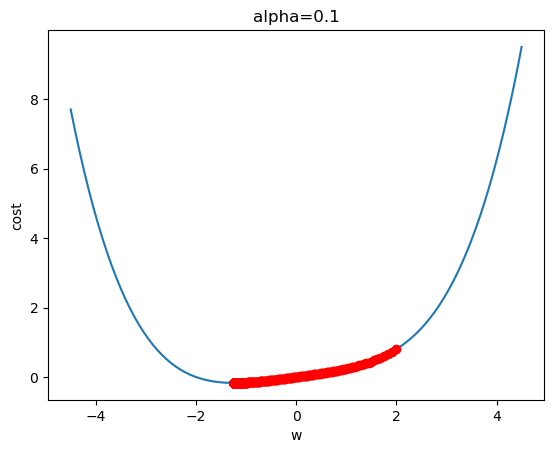

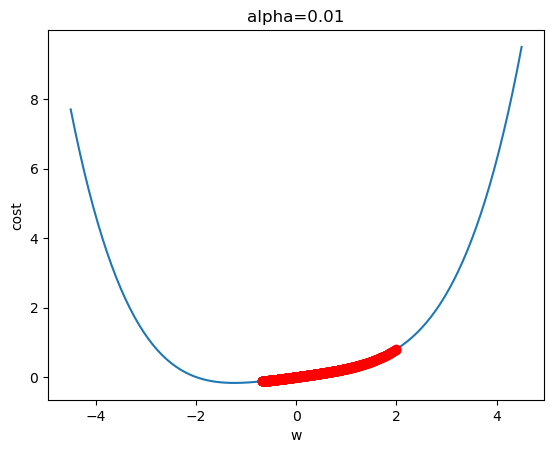

cost of alpha=1: -0.16996928446309353 
cost of alpha=0.1: -0.16996928446309353 
cost of alpha=0.01 -0.12249665467157389


In [20]:
g = lambda w: (w**4+w**2+10*w)/50.0
w = 2.0;  max_its = 1000;
wlist= np.linspace(-4.5, 4.5, 100)
costlist=[g(w) for w in wlist]
flist=[]

for alpha in [1,0.1,0.01]:
    weight_history,cost_history =gradient_descent(g,alpha,max_its,w)
    flist.append(cost_history[-1])
    plt.plot(wlist,costlist)
    plt.plot(weight_history,cost_history,marker='o',color='red')
    plt.title('alpha='+str(alpha))
    plt.xlabel('w')
    plt.ylabel('cost')
    plt.show()

print( 'cost of alpha=1:',flist[0],'\ncost of alpha=0.1:',flist[1],'\ncost of alpha=0.01',flist[2])

Hence, alpha=1 and alpha=0.1 both work best for it.